In [4]:
#Import Libararies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
import pandas as pd
df = pd.read_csv("recruitment_data.csv")

print(df.shape)          # rows x columns
print(df.isnull().sum()) # missing values
print(df.dtypes)         # column types
print(df['HiringDecision'].value_counts()) # class balance

(1500, 11)
Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
PersonalityScore       0
RecruitmentStrategy    0
HiringDecision         0
dtype: int64
Age                      int64
Gender                   int64
EducationLevel           int64
ExperienceYears          int64
PreviousCompanies        int64
DistanceFromCompany    float64
InterviewScore           int64
SkillScore               int64
PersonalityScore         int64
RecruitmentStrategy      int64
HiringDecision           int64
dtype: object
HiringDecision
0    1035
1     465
Name: count, dtype: int64


In [5]:
#Load data
df = pd.read_csv("recruitment_data.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1500, 11)

First 5 rows:


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26,1,2,0,3,26.783828,48,78,91,1,1
1,39,1,4,12,3,25.862694,35,68,80,2,1
2,48,0,2,3,2,9.920805,20,67,13,2,0
3,34,1,2,5,2,6.407751,36,27,70,3,0
4,30,0,1,6,1,43.105343,23,52,85,2,0


In [6]:
#EDA
print("=== Dataset Info ===")
print(df.info())

print("\n=== Statistical Summary ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Class Balance ===")
print(df['HiringDecision'].value_counts())
print(df['HiringDecision'].value_counts(normalize=True).round(3) * 100)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1500 non-null   int64  
 1   Gender               1500 non-null   int64  
 2   EducationLevel       1500 non-null   int64  
 3   ExperienceYears      1500 non-null   int64  
 4   PreviousCompanies    1500 non-null   int64  
 5   DistanceFromCompany  1500 non-null   float64
 6   InterviewScore       1500 non-null   int64  
 7   SkillScore           1500 non-null   int64  
 8   PersonalityScore     1500 non-null   int64  
 9   RecruitmentStrategy  1500 non-null   int64  
 10  HiringDecision       1500 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 129.0 KB
None

=== Statistical Summary ===
               Age       Gender  EducationLevel  ExperienceYears  \
count  1500.000000  1500.000000     1500.000000      1500.000000   

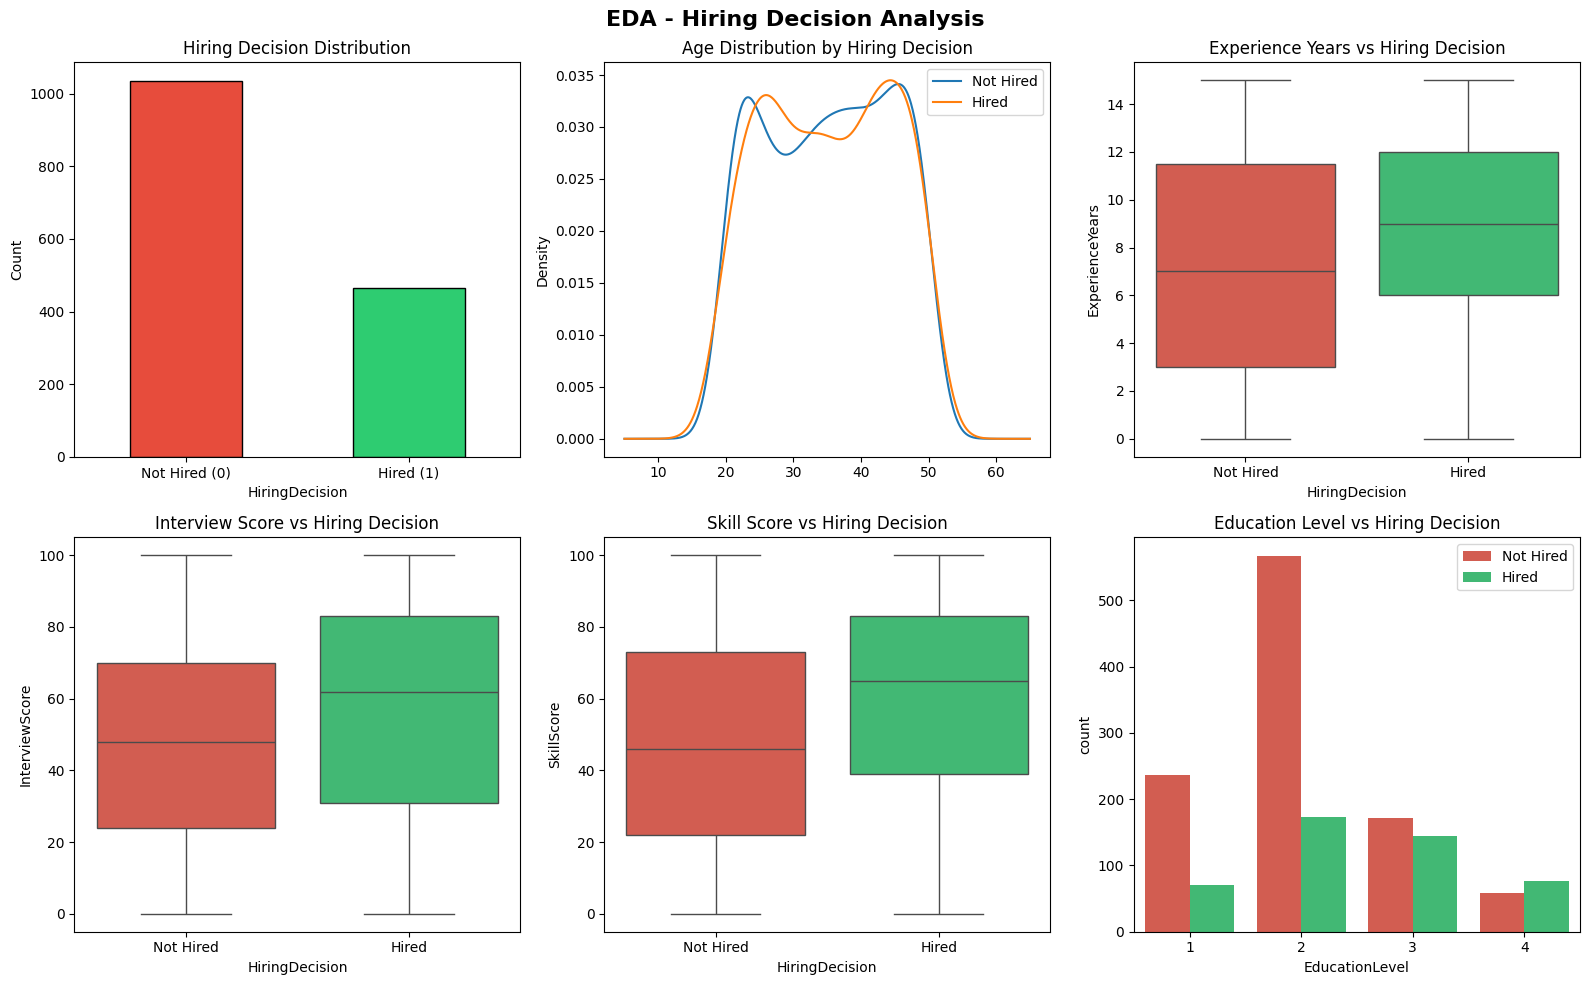

EDA plot saved!


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA - Hiring Decision Analysis', fontsize=16, fontweight='bold')

# 1. Class Balance
df['HiringDecision'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0,0].set_title('Hiring Decision Distribution')
axes[0,0].set_xticklabels(['Not Hired (0)', 'Hired (1)'], rotation=0)
axes[0,0].set_ylabel('Count')

# 2. Age Distribution by Decision
df.groupby('HiringDecision')['Age'].plot(kind='kde', ax=axes[0,1], legend=True)
axes[0,1].set_title('Age Distribution by Hiring Decision')
axes[0,1].legend(['Not Hired', 'Hired'])

# 3. Experience vs Hiring
sns.boxplot(data=df, x='HiringDecision', y='ExperienceYears', ax=axes[0,2],
            palette=['#e74c3c','#2ecc71'])
axes[0,2].set_title('Experience Years vs Hiring Decision')
axes[0,2].set_xticklabels(['Not Hired', 'Hired'])

# 4. Interview Score vs Hiring
sns.boxplot(data=df, x='HiringDecision', y='InterviewScore', ax=axes[1,0],
            palette=['#e74c3c','#2ecc71'])
axes[1,0].set_title('Interview Score vs Hiring Decision')
axes[1,0].set_xticklabels(['Not Hired', 'Hired'])

# 5. Skill Score vs Hiring
sns.boxplot(data=df, x='HiringDecision', y='SkillScore', ax=axes[1,1],
            palette=['#e74c3c','#2ecc71'])
axes[1,1].set_title('Skill Score vs Hiring Decision')
axes[1,1].set_xticklabels(['Not Hired', 'Hired'])

# 6. Education Level
sns.countplot(data=df, x='EducationLevel', hue='HiringDecision', ax=axes[1,2],
              palette=['#e74c3c','#2ecc71'])
axes[1,2].set_title('Education Level vs Hiring Decision')
axes[1,2].legend(['Not Hired', 'Hired'])

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plot saved!")

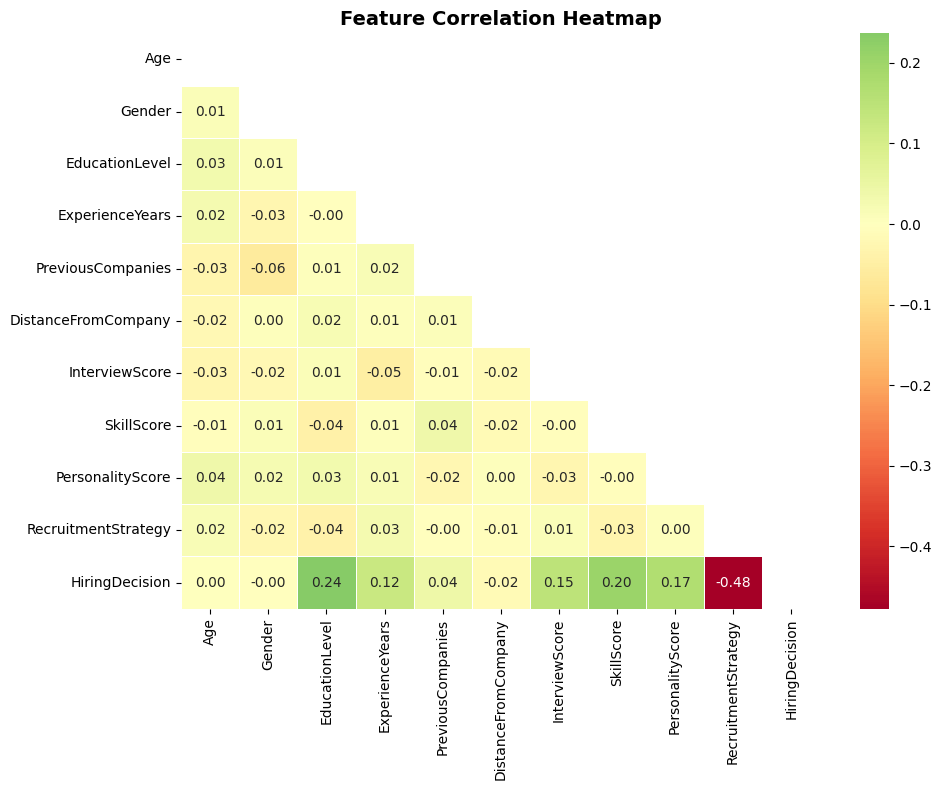

In [8]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [9]:
# Features and Target
X = df.drop('HiringDecision', axis=1)
y = df['HiringDecision']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Target balance in train:\n{y_train.value_counts()}")

Training set: (1200, 10)
Test set:     (300, 10)
Target balance in train:
HiringDecision
0    828
1    372
Name: count, dtype: int64


In [10]:
#Traning Models
# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Both models training Completely!")

Both models trained successfully!


In [11]:
#Evaluate
def evaluate_model(name, y_test, preds, proba):
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"Accuracy  : {accuracy_score(y_test, preds):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_test, proba):.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, preds)}")

evaluate_model("Logistic Regression", y_test, lr_preds, lr_proba)
evaluate_model("Random Forest",       y_test, rf_preds, rf_proba)


  Logistic Regression
Accuracy  : 0.8567
ROC-AUC   : 0.8911

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       207
           1       0.81      0.70      0.75        93

    accuracy                           0.86       300
   macro avg       0.84      0.81      0.83       300
weighted avg       0.85      0.86      0.85       300


  Random Forest
Accuracy  : 0.9400
ROC-AUC   : 0.9287

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       207
           1       0.95      0.85      0.90        93

    accuracy                           0.94       300
   macro avg       0.94      0.92      0.93       300
weighted avg       0.94      0.94      0.94       300



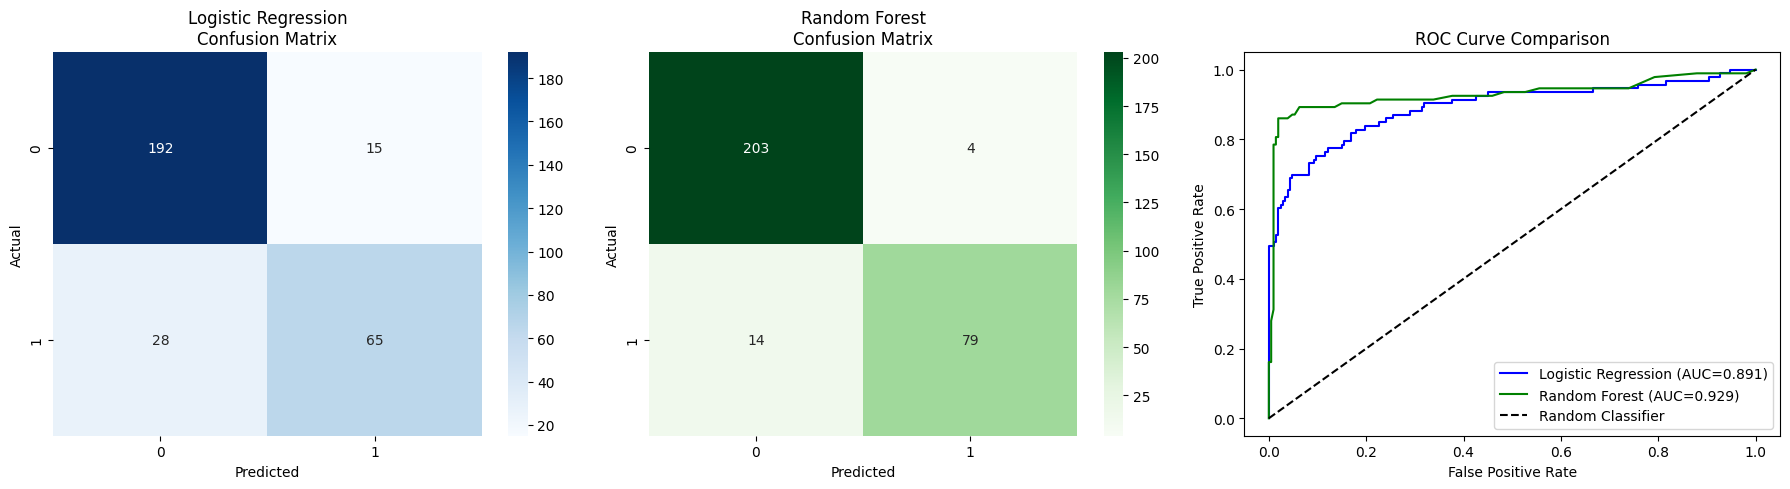

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix - LR
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d',
            cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix - RF
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d',
            cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest\nConfusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# ROC Curve - Both
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

axes[2].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, lr_proba):.3f})', color='blue')
axes[2].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, rf_proba):.3f})', color='green')
axes[2].plot([0,1],[0,1], 'k--', label='Random Classifier')
axes[2].set_title('ROC Curve Comparison')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150)
plt.show()

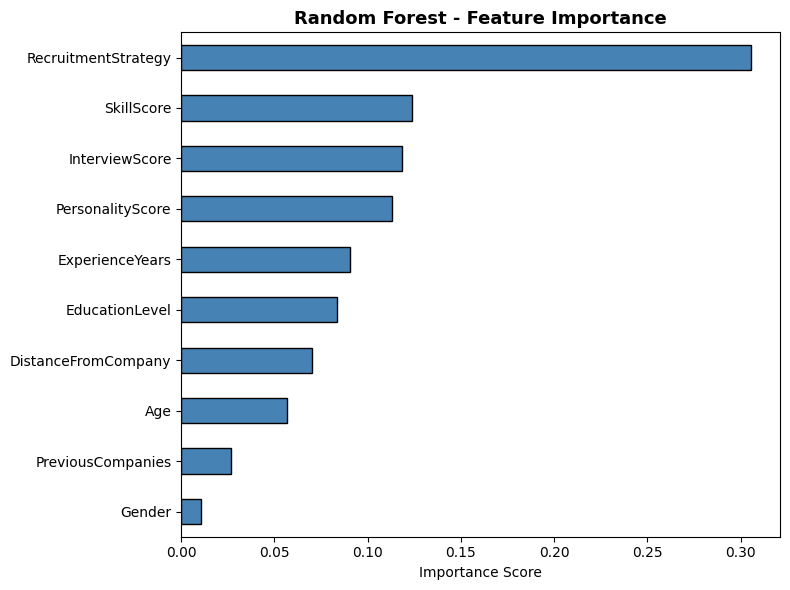

In [13]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances_sorted.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Random Forest - Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [14]:
lr_acc = accuracy_score(y_test, lr_preds)
rf_acc = accuracy_score(y_test, rf_preds)
lr_auc = roc_auc_score(y_test, lr_proba)
rf_auc = roc_auc_score(y_test, rf_proba)

print("=" * 40)
print("       FINAL MODEL COMPARISON")
print("=" * 40)
print(f"{'Model':<25} {'Accuracy':>8} {'ROC-AUC':>8}")
print("-" * 40)
print(f"{'Logistic Regression':<25} {lr_acc:>8.4f} {lr_auc:>8.4f}")
print(f"{'Random Forest':<25} {rf_acc:>8.4f} {rf_auc:>8.4f}")
print("=" * 40)

winner = "Random Forest" if rf_acc > lr_acc else "Logistic Regression"
print(f"\nBest Model: {winner}")
print("\nDataset Source: kaggle.com/datasets/rabieelkharoua/")
print("predicting-hiring-decisions-in-recruitment-data")

       FINAL MODEL COMPARISON
Model                     Accuracy  ROC-AUC
----------------------------------------
Logistic Regression         0.8567   0.8911
Random Forest               0.9400   0.9287

Best Model: Random Forest

Dataset Source: kaggle.com/datasets/rabieelkharoua/
predicting-hiring-decisions-in-recruitment-data


In [15]:
reqs = """pandas
numpy
matplotlib
seaborn
scikit-learn"""

with open("requirements.txt", "w") as f:
    f.write(reqs)
print("requirements.txt created")

requirements.txt created


In [16]:
readme = """# Kravix Tech - ML Internship Assessment

## Problem
Predict whether a candidate will be hired based on profile features.

## Dataset
Source: kaggle.com/datasets/rabieelkharoua/predicting-hiring-decisions-in-recruitment-data
Rows: 1500 | Features: 10 | Target: HiringDecision (0/1)

## Models Trained
- Logistic Regression — Accuracy: 85.67%, ROC-AUC: 0.8911
- Random Forest — Accuracy: 94.00%, ROC-AUC: 0.9287

## Best Model: Random Forest

## Setup
```bash
pip install -r requirements.txt
```
Run the notebook: `kravix_assessment.ipynb`
"""

with open("README.md", "w") as f:
    f.write(readme)
print("README.md created")

README.md created
